In [1]:
# If required, run this once in a Jupyter cell:
# !pip install pandas numpy matplotlib seaborn statsmodels scikit-learn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt,
    ExponentialSmoothing
)

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the FreshMart sales dataset
df = pd.read_csv("FreshMart_Monthly_Sales.csv")

# Convert Month column to datetime
df["Month"] = pd.to_datetime(df["Month"], format="%b-%y")

# Sort by month
df = df.sort_values("Month").reset_index(drop=True)

# Set Month as index
df.set_index("Month", inplace=True)

# Display first few rows
print("Dataset shape:", df.shape)
display(df.head(10))

Dataset shape: (60, 1)


,Sales
Month,
2020-01-01,54.99
2020-02-01,52.98
2020-03-01,54.14
2020-04-01,57.15
2020-05-01,55.23
2020-06-01,54.65
2020-07-01,54.70
2020-08-01,48.67
2020-09-01,44.45


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
print(df.describe())

Missing values:
Sales    0
dtype: int64

Data types:
Sales    float64
dtype: object

Dataset information:
           Sales
count  60.000000
mean   62.191000
std     8.194725
min    44.450000
25%    55.170000
50%    61.400000
75%    68.110000
max    79.950000


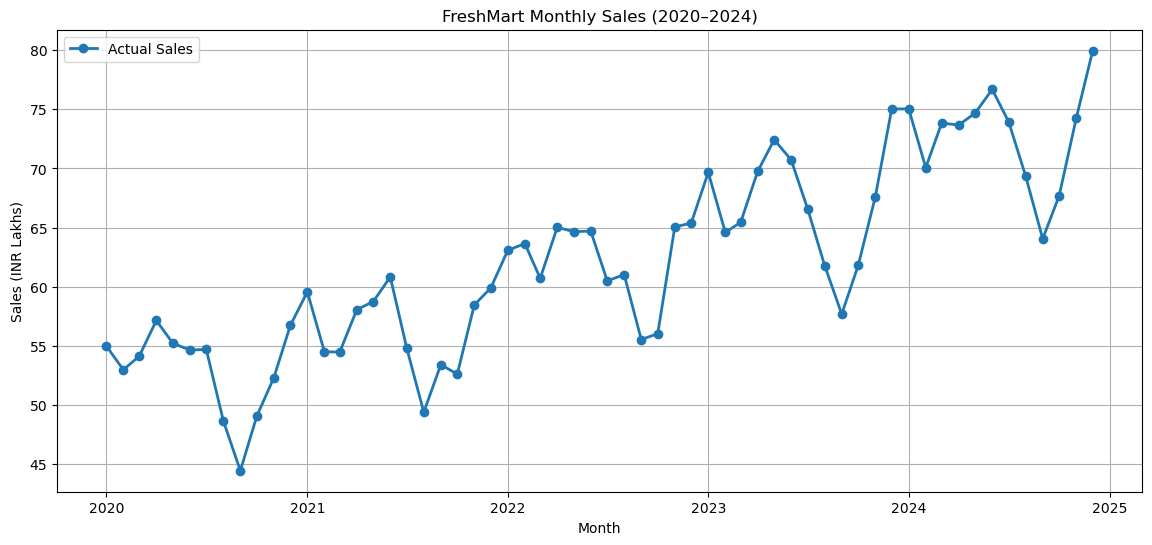

In [4]:
plt.figure(figsize=(14, 6))

plt.plot(
    df.index,
    df["Sales"],
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.title("FreshMart Monthly Sales (2020–2024)")
plt.xlabel("Month")
plt.ylabel("Sales (INR Lakhs)")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Create a copy for Task 1
ma_df = df.copy()

# Calculate moving averages
ma_df["MA_3"] = ma_df["Sales"].rolling(window=3).mean()
ma_df["MA_6"] = ma_df["Sales"].rolling(window=6).mean()
ma_df["MA_12"] = ma_df["Sales"].rolling(window=12).mean()

# Display results
display(ma_df.head(15))

,Sales,MA_3,MA_6,MA_12
Month,,,,
2020-01-01,54.99,NaN,NaN,NaN
2020-02-01,52.98,NaN,NaN,NaN
2020-03-01,54.14,54.036667,NaN,NaN
2020-04-01,57.15,54.756667,NaN,NaN
2020-05-01,55.23,55.506667,NaN,NaN
2020-06-01,54.65,55.676667,54.856667,NaN
2020-07-01,54.70,54.860000,54.808333,NaN
2020-08-01,48.67,52.673333,54.090000,NaN
2020-09-01,44.45,49.273333,52.475000,NaN


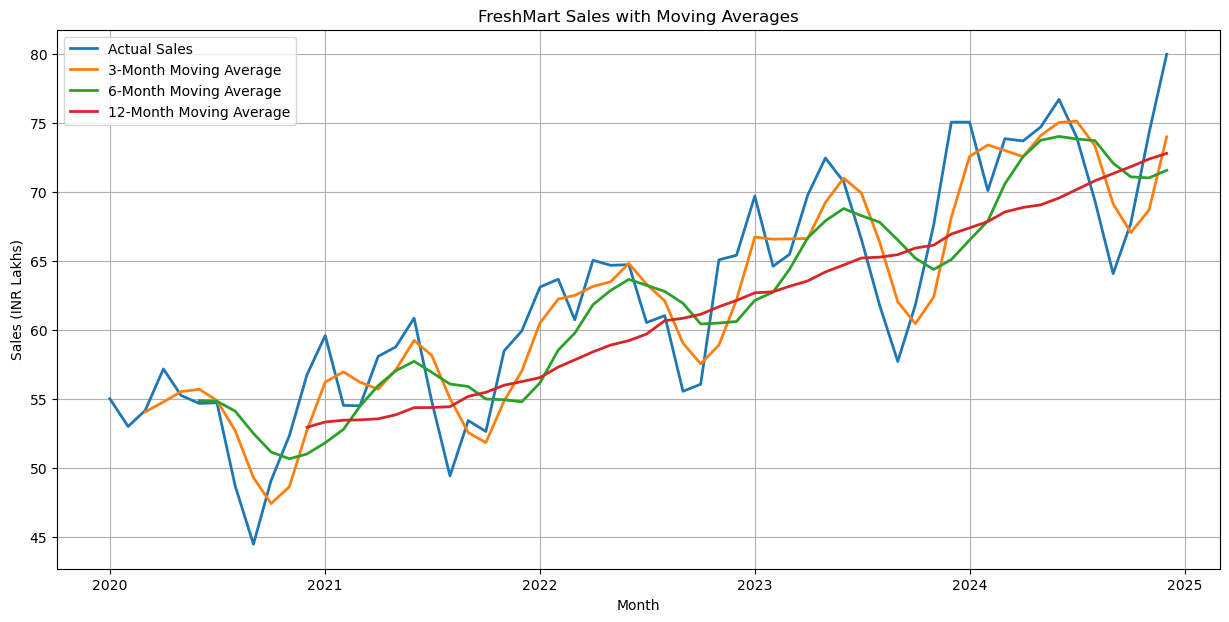

In [6]:
plt.figure(figsize=(15, 7))

plt.plot(
    ma_df.index,
    ma_df["Sales"],
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    ma_df.index,
    ma_df["MA_3"],
    label="3-Month Moving Average",
    linewidth=2
)

plt.plot(
    ma_df.index,
    ma_df["MA_6"],
    label="6-Month Moving Average",
    linewidth=2
)

plt.plot(
    ma_df.index,
    ma_df["MA_12"],
    label="12-Month Moving Average",
    linewidth=2
)

plt.title("FreshMart Sales with Moving Averages")
plt.xlabel("Month")
plt.ylabel("Sales (INR Lakhs)")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# Calculate the variation of each moving average
ma_variability = {
    "3-Month MA": ma_df["MA_3"].std(),
    "6-Month MA": ma_df["MA_6"].std(),
    "12-Month MA": ma_df["MA_12"].std()
}

ma_variability_df = pd.DataFrame(
    list(ma_variability.items()),
    columns=["Moving Average", "Standard Deviation"]
)

display(ma_variability_df)

,Moving Average,Standard Deviation
0,3-Month MA,7.513621
1,6-Month MA,6.994961
2,12-Month MA,6.123136


In [8]:
# Create a separate Excel file containing actual sales
# and the 3, 6 and 12 month moving averages

task1_excel = ma_df.reset_index()

# Save the Excel file
task1_excel.to_excel(
    "FreshMart_Task1_Moving_Averages.xlsx",
    index=False
)

print("Excel file created successfully!")
print("File name: FreshMart_Task1_Moving_Averages.xlsx")

Excel file created successfully!
File name: FreshMart_Task1_Moving_Averages.xlsx


In [9]:
import os

print(os.getcwd())

C:\Users\parve\OneDrive\Desktop\BA 3\Sec B Project


In [10]:
# Use the last 12 months as test data
train = df["Sales"].iloc[:-12]
test = df["Sales"].iloc[-12:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 48
Testing observations: 12

Training period:
2020-01-01 00:00:00 to 2023-12-01 00:00:00

Testing period:
2024-01-01 00:00:00 to 2024-12-01 00:00:00


In [11]:
def MAPE(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    return np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100


def RMSE(actual, predicted):
    return np.sqrt(
        mean_squared_error(actual, predicted)
    )

In [12]:
# Test different alpha values
alpha_values = np.arange(0.01, 1.00, 0.01)

ses_results = []

for alpha in alpha_values:
    
    model = SimpleExpSmoothing(train).fit(
        smoothing_level=alpha,
        optimized=False
    )
    
    forecast = model.forecast(len(test))
    
    rmse = RMSE(test, forecast)
    mape = MAPE(test, forecast)
    
    ses_results.append([
        alpha,
        rmse,
        mape
    ])

ses_results_df = pd.DataFrame(
    ses_results,
    columns=["Alpha", "RMSE", "MAPE"]
)

display(ses_results_df.head())

,Alpha,RMSE,MAPE
0,0.01,16.288099,21.405321
1,0.02,14.664406,19.083278
2,0.03,13.328395,17.156366
3,0.04,12.236147,15.566099
4,0.05,11.346410,14.257467


In [13]:
best_ses = ses_results_df.loc[
    ses_results_df["RMSE"].idxmin()
]

print("Best Alpha based on RMSE:")
display(best_ses)

Best Alpha based on RMSE:


Alpha    0.750000
RMSE     4.101398
MAPE     4.650899
Name: 74, dtype: float64

In [14]:
best_alpha = best_ses["Alpha"]

ses_model = SimpleExpSmoothing(train).fit(
    smoothing_level=best_alpha,
    optimized=False
)

ses_forecast = ses_model.forecast(len(test))

ses_rmse = RMSE(test, ses_forecast)
ses_mape = MAPE(test, ses_forecast)

print("SES Results")
print("Alpha:", best_alpha)
print("RMSE:", round(ses_rmse, 3))
print("MAPE:", round(ses_mape, 3), "%")

SES Results
Alpha: 0.75
RMSE: 4.101
MAPE: 4.651 %


In [15]:
alpha_values = np.arange(0.1, 1.0, 0.1)
beta_values = np.arange(0.1, 1.0, 0.1)

double_results = []

for alpha in alpha_values:
    
    for beta in beta_values:
        
        try:
            model = Holt(
                train,
                exponential=False,
                damped_trend=False
            ).fit(
                smoothing_level=alpha,
                smoothing_trend=beta,
                optimized=False
            )
            
            forecast = model.forecast(len(test))
            
            rmse = RMSE(test, forecast)
            mape = MAPE(test, forecast)
            
            double_results.append([
                alpha,
                beta,
                rmse,
                mape
            ])
            
        except:
            pass


double_results_df = pd.DataFrame(
    double_results,
    columns=["Alpha", "Beta", "RMSE", "MAPE"]
)

display(double_results_df.head())

,Alpha,Beta,RMSE,MAPE
0,0.1,0.1,4.894831,5.265461
1,0.1,0.2,5.303290,6.285963
2,0.1,0.3,6.469443,7.657670
3,0.1,0.4,5.783481,6.960029
4,0.1,0.5,5.716711,6.824664


In [16]:
best_double = double_results_df.loc[
    double_results_df["RMSE"].idxmin()
]

print("Best Double Exponential Smoothing parameters:")
display(best_double)

Best Double Exponential Smoothing parameters:


Alpha    0.400000
Beta     0.100000
RMSE     4.605123
MAPE     5.571685
Name: 27, dtype: float64

In [17]:
best_alpha_double = best_double["Alpha"]
best_beta_double = best_double["Beta"]

double_model = Holt(
    train,
    exponential=False,
    damped_trend=False
).fit(
    smoothing_level=best_alpha_double,
    smoothing_trend=best_beta_double,
    optimized=False
)

double_forecast = double_model.forecast(len(test))

double_rmse = RMSE(test, double_forecast)
double_mape = MAPE(test, double_forecast)

print("Double Exponential Smoothing")
print("Alpha:", best_alpha_double)
print("Beta:", best_beta_double)
print("RMSE:", round(double_rmse, 3))
print("MAPE:", round(double_mape, 3), "%")

Double Exponential Smoothing
Alpha: 0.4
Beta: 0.1
RMSE: 4.605
MAPE: 5.572 %


In [18]:
# Holt-Winters with additive trend and additive seasonality

triple_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

triple_forecast = triple_model.forecast(len(test))

triple_rmse = RMSE(test, triple_forecast)
triple_mape = MAPE(test, triple_forecast)

print("Triple Exponential Smoothing / Holt-Winters")
print("RMSE:", round(triple_rmse, 3))
print("MAPE:", round(triple_mape, 3), "%")

Triple Exponential Smoothing / Holt-Winters
RMSE: 1.968
MAPE: 2.224 %


In [19]:
task2_results = pd.DataFrame({
    "Model": [
        "Simple Exponential Smoothing",
        "Double Exponential Smoothing",
        "Triple Exponential Smoothing"
    ],
    
    "RMSE": [
        ses_rmse,
        double_rmse,
        triple_rmse
    ],
    
    "MAPE (%)": [
        ses_mape,
        double_mape,
        triple_mape
    ]
})

display(task2_results)

,Model,RMSE,MAPE (%)
0,Simple Exponential Smoothing,4.101398,4.650899
1,Double Exponential Smoothing,4.605123,5.571685
2,Triple Exponential Smoothing,1.967810,2.223610


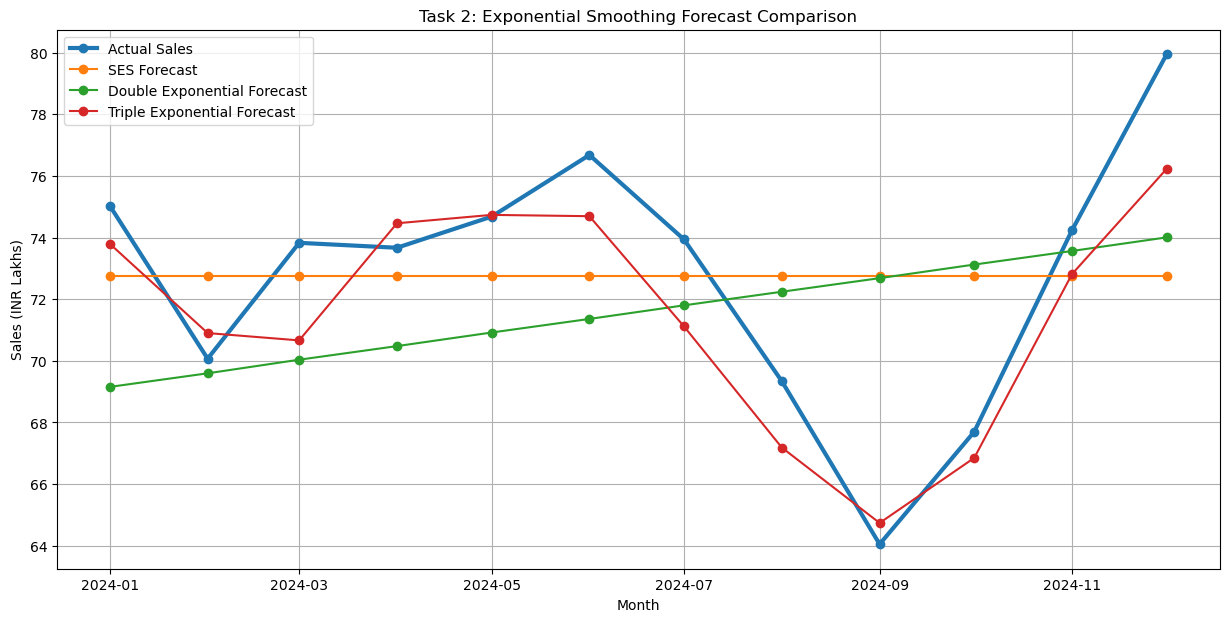

In [20]:
plt.figure(figsize=(15, 7))

plt.plot(
    test.index,
    test,
    marker="o",
    linewidth=3,
    label="Actual Sales"
)

plt.plot(
    test.index,
    ses_forecast,
    marker="o",
    label="SES Forecast"
)

plt.plot(
    test.index,
    double_forecast,
    marker="o",
    label="Double Exponential Forecast"
)

plt.plot(
    test.index,
    triple_forecast,
    marker="o",
    label="Triple Exponential Forecast"
)

plt.title("Task 2: Exponential Smoothing Forecast Comparison")
plt.xlabel("Month")
plt.ylabel("Sales (INR Lakhs)")
plt.legend()
plt.grid(True)
plt.show()

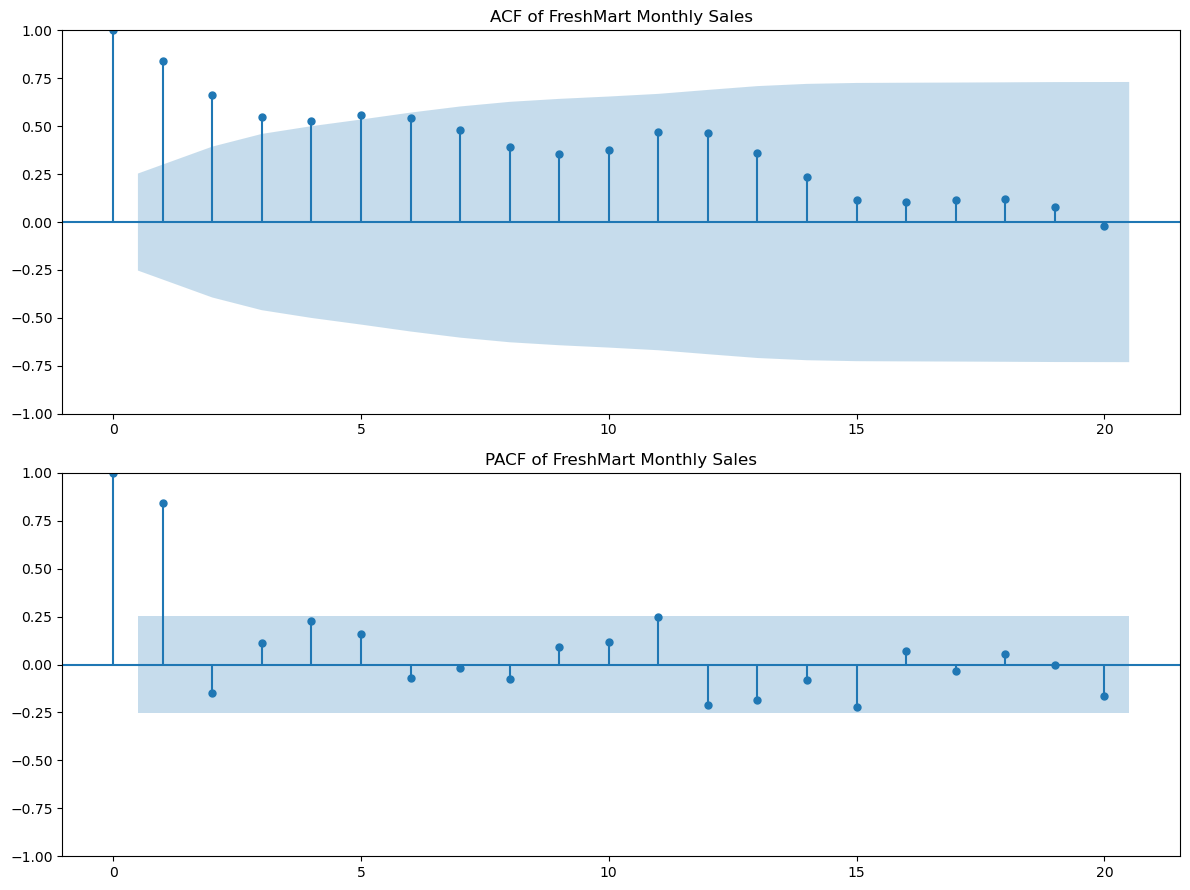

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

plot_acf(
    df["Sales"],
    lags=20,
    ax=axes[0]
)

axes[0].set_title("ACF of FreshMart Monthly Sales")

plot_pacf(
    df["Sales"],
    lags=20,
    ax=axes[1],
    method="ywm"
)

axes[1].set_title("PACF of FreshMart Monthly Sales")

plt.tight_layout()
plt.show()

In [22]:
ar_results = []

ar_forecasts = {}

for lag in [1, 2, 3]:
    
    ar_model = AutoReg(
        train,
        lags=lag,
        trend="c"
    ).fit()
    
    forecast = ar_model.predict(
        start=len(train),
        end=len(train) + len(test) - 1
    )
    
    rmse = RMSE(test, forecast)
    mape = MAPE(test, forecast)
    
    ar_results.append([
        f"AR({lag})",
        rmse,
        mape
    ])
    
    ar_forecasts[f"AR({lag})"] = forecast


ar_results_df = pd.DataFrame(
    ar_results,
    columns=["Model", "RMSE", "MAPE"]
)

display(ar_results_df)

,Model,RMSE,MAPE
0,AR(1),6.417282,6.861511
1,AR(2),8.787243,9.738179
2,AR(3),8.587326,9.453230


In [23]:
best_ar = ar_results_df.loc[
    ar_results_df["RMSE"].idxmin()
]

print("AR model with lowest RMSE:")
display(best_ar)

AR model with lowest RMSE:


Model       AR(1)
RMSE     6.417282
MAPE     6.861511
Name: 0, dtype: object

In [24]:
def adf_test(series):
    
    result = adfuller(series.dropna())
    
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    
    for key, value in result[4].items():
        print(f"{key}: {value}")
        
    if result[1] <= 0.05:
        print("\nResult: The series is stationary.")
    else:
        print("\nResult: The series is not stationary.")


adf_test(train)

ADF Statistic: 0.47034285402532466
p-value: 0.9839432644275006
Critical Values:
1%: -3.6209175221605827
5%: -2.9435394610388332
10%: -2.6104002410518627

Result: The series is not stationary.


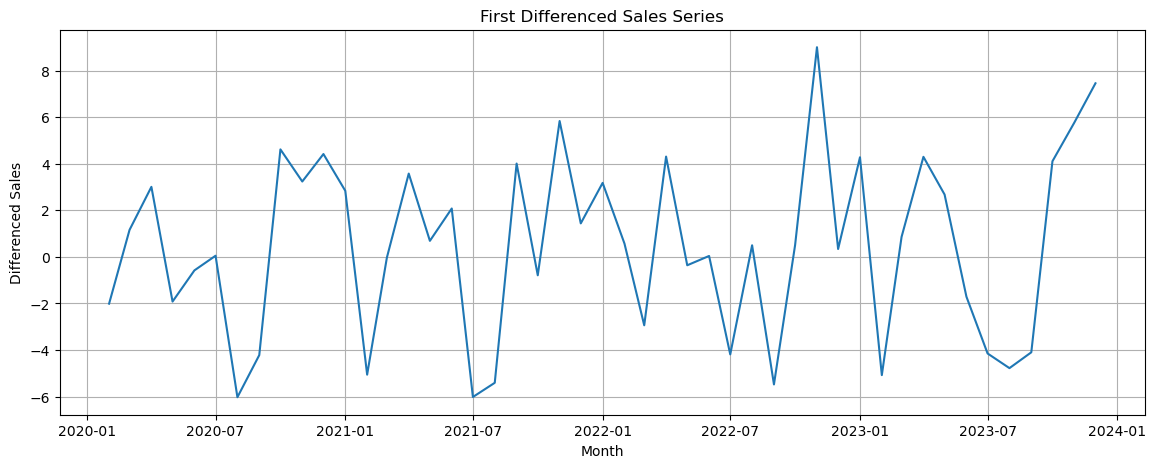

In [25]:
train_diff = train.diff().dropna()

plt.figure(figsize=(14, 5))

plt.plot(train_diff)

plt.title("First Differenced Sales Series")
plt.xlabel("Month")
plt.ylabel("Differenced Sales")
plt.grid(True)

plt.show()

In [26]:
adf_test(train_diff)

ADF Statistic: -7.215501134140445
p-value: 2.1785890634128238e-10
Critical Values:
1%: -3.6209175221605827
5%: -2.9435394610388332
10%: -2.6104002410518627

Result: The series is stationary.


In [27]:
adf_original = adfuller(train.dropna())

if adf_original[1] <= 0.05:
    d = 0
else:
    adf_difference = adfuller(train.diff().dropna())
    
    if adf_difference[1] <= 0.05:
        d = 1
    else:
        d = 2

print("Selected d =", d)

Selected d = 1


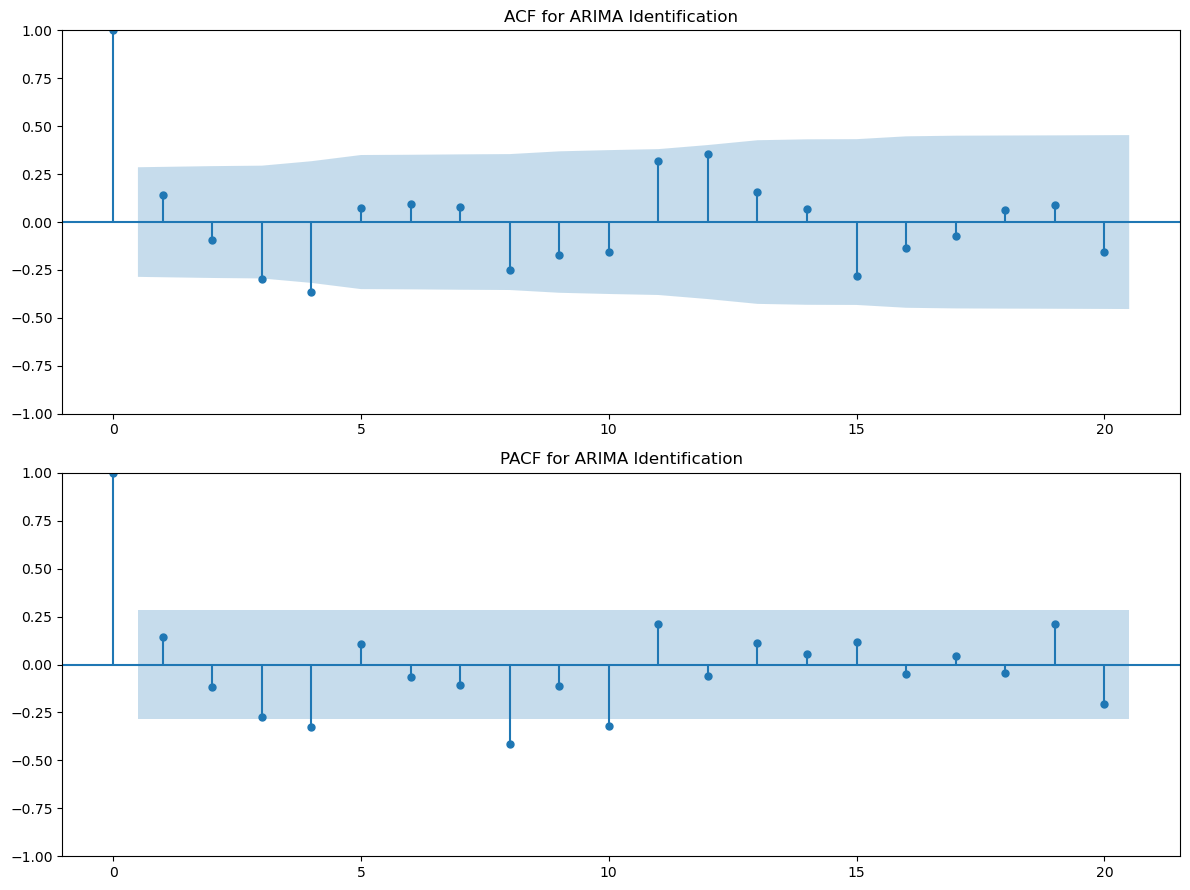

In [28]:
series_for_acf = train.copy()

if d > 0:
    for _ in range(d):
        series_for_acf = series_for_acf.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

plot_acf(
    series_for_acf,
    lags=20,
    ax=axes[0]
)

axes[0].set_title("ACF for ARIMA Identification")

plot_pacf(
    series_for_acf,
    lags=20,
    ax=axes[1],
    method="ywm"
)

axes[1].set_title("PACF for ARIMA Identification")

plt.tight_layout()
plt.show()

In [29]:
arima_results = []

for p in range(0, 4):
    
    for q in range(0, 4):
        
        try:
            model = ARIMA(
                train,
                order=(p, d, q)
            ).fit()
            
            forecast = model.forecast(len(test))
            
            rmse = RMSE(test, forecast)
            mape = MAPE(test, forecast)
            
            arima_results.append([
                p,
                d,
                q,
                model.aic,
                rmse,
                mape
            ])
            
        except:
            pass


arima_results_df = pd.DataFrame(
    arima_results,
    columns=[
        "p",
        "d",
        "q",
        "AIC",
        "RMSE",
        "MAPE"
    ]
)

display(
    arima_results_df.sort_values("RMSE").head(10)
)

,p,d,q,AIC,RMSE,MAPE
15,3,1,3,255.824703,2.927527,3.373783
10,2,1,2,255.056293,3.099505,3.627693
14,3,1,2,256.432176,3.448625,3.824523
12,3,1,0,262.368724,4.540939,5.396739
8,2,1,0,264.399249,4.591111,4.717712
0,0,1,0,262.126150,4.685262,4.836553
5,1,1,1,264.813078,5.280254,5.851488
1,0,1,1,262.817664,5.338891,5.935297
6,1,1,2,262.488300,5.356467,5.899831
4,1,1,0,262.965815,5.515873,6.174041


In [30]:
best_arima = arima_results_df.loc[
    arima_results_df["RMSE"].idxmin()
]

print("Best ARIMA model based on RMSE:")
display(best_arima)

Best ARIMA model based on RMSE:


p         3.000000
d         1.000000
q         3.000000
AIC     255.824703
RMSE      2.927527
MAPE      3.373783
Name: 15, dtype: float64

In [31]:
best_p = int(best_arima["p"])
best_d = int(best_arima["d"])
best_q = int(best_arima["q"])

arima_model = ARIMA(
    train,
    order=(best_p, best_d, best_q)
).fit()

arima_forecast = arima_model.forecast(len(test))

arima_rmse = RMSE(test, arima_forecast)
arima_mape = MAPE(test, arima_forecast)

print(
    f"ARIMA({best_p},{best_d},{best_q})"
)

print("RMSE:", round(arima_rmse, 3))
print("MAPE:", round(arima_mape, 3), "%")

ARIMA(3,1,3)
RMSE: 2.928
MAPE: 3.374 %


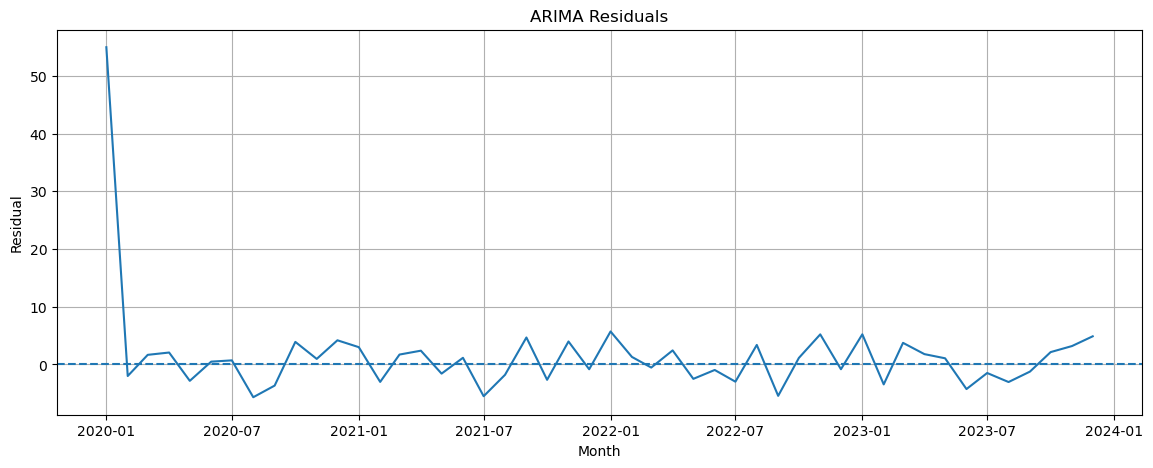

In [32]:
residuals = arima_model.resid

plt.figure(figsize=(14, 5))

plt.plot(residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("ARIMA Residuals")
plt.xlabel("Month")
plt.ylabel("Residual")
plt.grid(True)

plt.show()

<Figure size 1200x500 with 0 Axes>

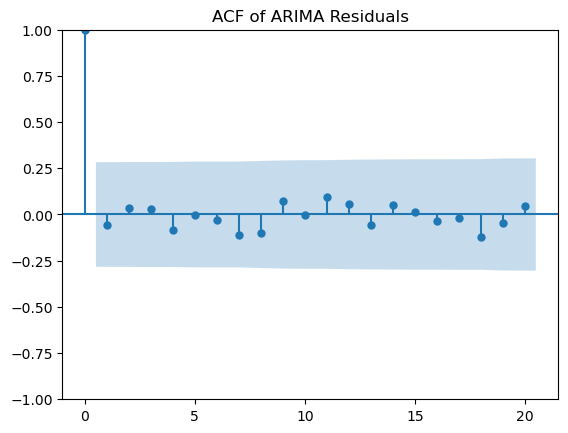

In [33]:
plt.figure(figsize=(12, 5))

plot_acf(
    residuals.dropna(),
    lags=20
)

plt.title("ACF of ARIMA Residuals")
plt.show()

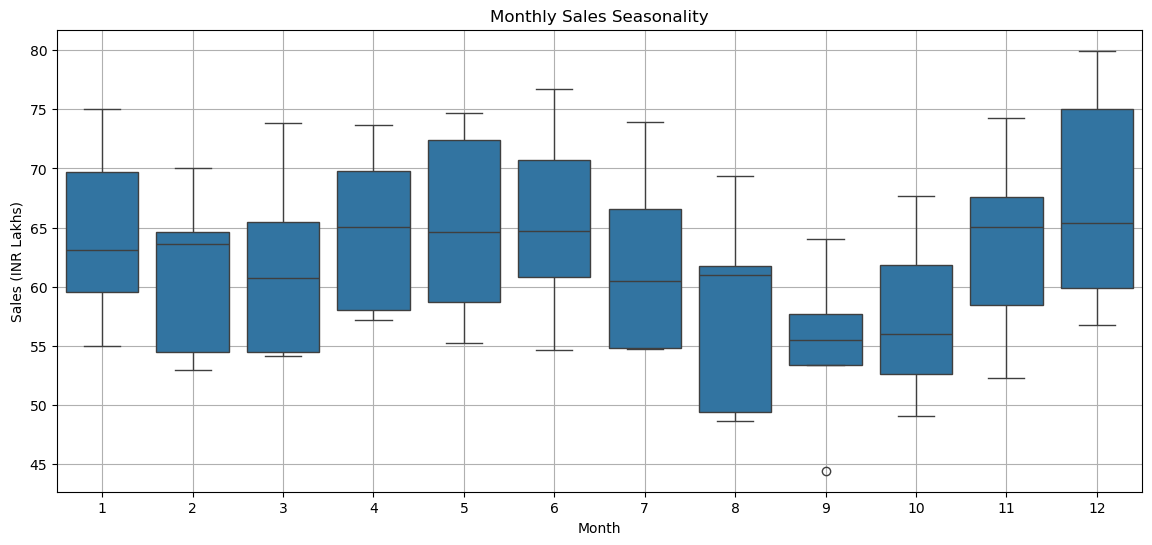

In [34]:
# Seasonal plot using month number

seasonal_df = df.copy()

seasonal_df["Year"] = seasonal_df.index.year
seasonal_df["Month_Number"] = seasonal_df.index.month
seasonal_df["Month_Name"] = seasonal_df.index.strftime("%b")

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=seasonal_df,
    x="Month_Number",
    y="Sales"
)

plt.title("Monthly Sales Seasonality")
plt.xlabel("Month")
plt.ylabel("Sales (INR Lakhs)")
plt.grid(True)

plt.show()

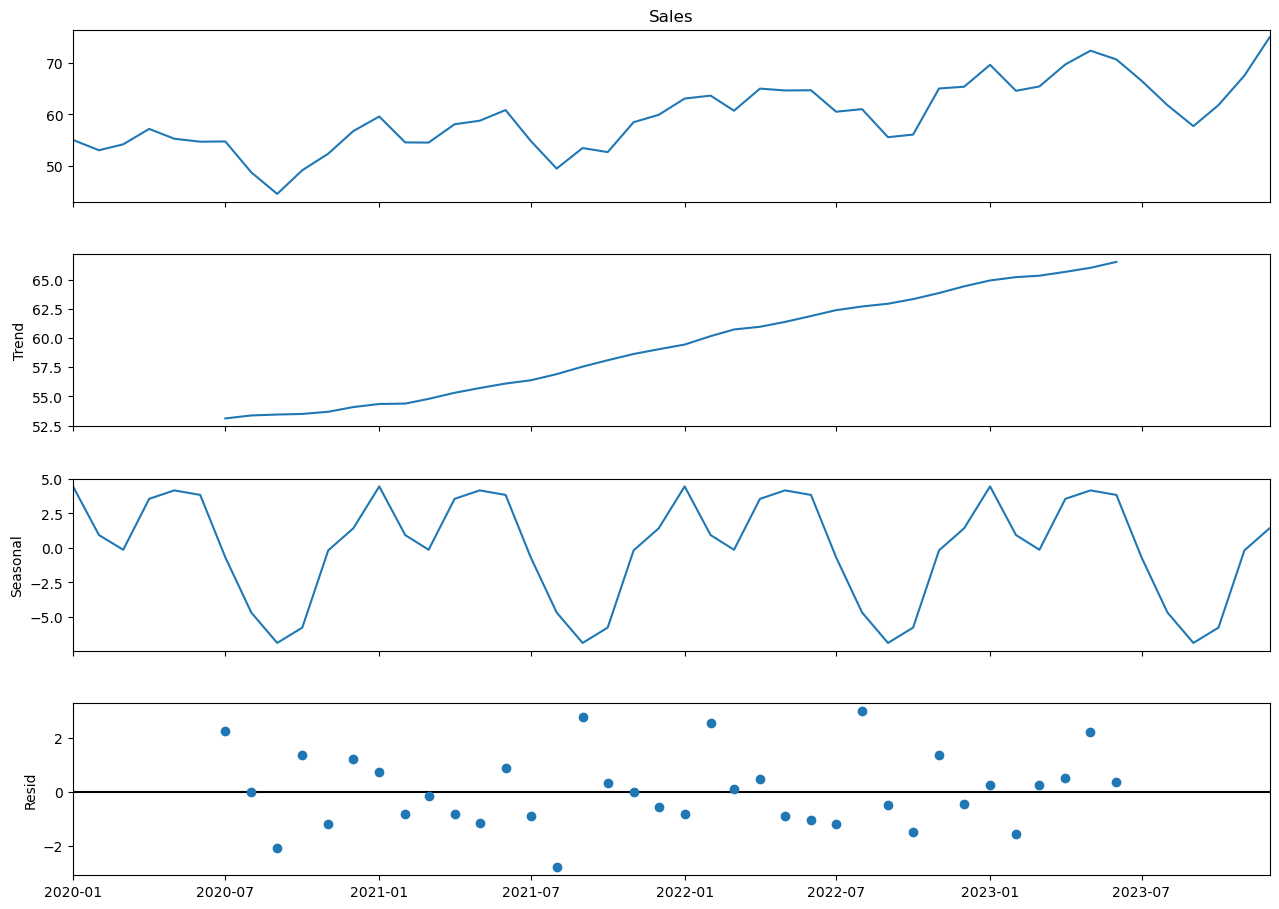

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    train,
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.show()

In [36]:
sarima_results = []

p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]

seasonal_period = 12

for p in p_values:
    for d_sarima in d_values:
        for q in q_values:
            
            for P in P_values:
                for D in D_values:
                    for Q in Q_values:
                        
                        try:
                            
                            model = SARIMAX(
                                train,
                                order=(p, d_sarima, q),
                                seasonal_order=(
                                    P,
                                    D,
                                    Q,
                                    seasonal_period
                                ),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            ).fit(disp=False)
                            
                            forecast = model.forecast(
                                len(test)
                            )
                            
                            rmse = RMSE(
                                test,
                                forecast
                            )
                            
                            mape = MAPE(
                                test,
                                forecast
                            )
                            
                            sarima_results.append([
                                p,
                                d_sarima,
                                q,
                                P,
                                D,
                                Q,
                                model.aic,
                                rmse,
                                mape
                            ])
                            
                        except:
                            pass


sarima_results_df = pd.DataFrame(
    sarima_results,
    columns=[
        "p",
        "d",
        "q",
        "P",
        "D",
        "Q",
        "AIC",
        "RMSE",
        "MAPE"
    ]
)

display(
    sarima_results_df.sort_values("RMSE").head(10)
)

,p,d,q,P,D,Q,AIC,RMSE,MAPE
124,2,1,0,1,0,0,178.670417,1.338363,1.394398
108,2,0,1,1,0,0,178.823381,1.378441,1.522970
115,2,0,2,0,1,1,103.330083,1.425172,1.769644
67,1,0,2,0,1,1,101.565652,1.438160,1.804974
111,2,0,1,1,1,1,107.800844,1.452314,1.750215
107,2,0,1,0,1,1,105.209745,1.474291,1.826947
59,1,0,1,0,1,1,103.226884,1.477009,1.816545
114,2,0,2,0,1,0,172.358133,1.584809,1.572732
58,1,0,1,0,1,0,175.429228,1.586888,1.565358
66,1,0,2,0,1,0,172.477632,1.588060,1.567592


In [37]:
best_sarima = sarima_results_df.loc[
    sarima_results_df["RMSE"].idxmin()
]

print("Best SARIMA model:")
display(best_sarima)

Best SARIMA model:


p         2.000000
d         1.000000
q         0.000000
P         1.000000
D         0.000000
Q         0.000000
AIC     178.670417
RMSE      1.338363
MAPE      1.394398
Name: 124, dtype: float64

In [38]:
sarima_p = int(best_sarima["p"])
sarima_d = int(best_sarima["d"])
sarima_q = int(best_sarima["q"])

sarima_P = int(best_sarima["P"])
sarima_D = int(best_sarima["D"])
sarima_Q = int(best_sarima["Q"])

sarima_model = SARIMAX(
    train,
    order=(
        sarima_p,
        sarima_d,
        sarima_q
    ),
    seasonal_order=(
        sarima_P,
        sarima_D,
        sarima_Q,
        12
    ),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_model.forecast(
    len(test)
)

sarima_rmse = RMSE(
    test,
    sarima_forecast
)

sarima_mape = MAPE(
    test,
    sarima_forecast
)

print(
    f"SARIMA({sarima_p},{sarima_d},{sarima_q})"
    f"({sarima_P},{sarima_D},{sarima_Q})[12]"
)

print("RMSE:", round(sarima_rmse, 3))
print("MAPE:", round(sarima_mape, 3), "%")

SARIMA(2,1,0)(1,0,0)[12]
RMSE: 1.338
MAPE: 1.394 %


In [39]:
hw_additive_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

hw_additive_forecast = hw_additive_model.forecast(
    len(test)
)

hw_additive_rmse = RMSE(
    test,
    hw_additive_forecast
)

hw_additive_mape = MAPE(
    test,
    hw_additive_forecast
)

print("Additive Holt-Winters")
print("RMSE:", round(hw_additive_rmse, 3))
print("MAPE:", round(hw_additive_mape, 3), "%")

Additive Holt-Winters
RMSE: 1.968
MAPE: 2.224 %


In [40]:
hw_multiplicative_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="mul",
    seasonal_periods=12
).fit()

hw_multiplicative_forecast = hw_multiplicative_model.forecast(
    len(test)
)

hw_multiplicative_rmse = RMSE(
    test,
    hw_multiplicative_forecast
)

hw_multiplicative_mape = MAPE(
    test,
    hw_multiplicative_forecast
)

print("Multiplicative Holt-Winters")
print(
    "RMSE:",
    round(hw_multiplicative_rmse, 3)
)

print(
    "MAPE:",
    round(hw_multiplicative_mape, 3),
    "%"
)

Multiplicative Holt-Winters
RMSE: 1.97
MAPE: 2.383 %


In [41]:
comparison_results = []

# SES
comparison_results.append([
    "SES",
    mean_absolute_error(test, ses_forecast),
    ses_rmse,
    ses_mape
])

# Double Exponential
comparison_results.append([
    "Double Exponential",
    mean_absolute_error(test, double_forecast),
    double_rmse,
    double_mape
])

# Triple Exponential
comparison_results.append([
    "Triple Exponential / Holt-Winters",
    mean_absolute_error(test, triple_forecast),
    triple_rmse,
    triple_mape
])

# AR models
for model_name, forecast in ar_forecasts.items():
    
    comparison_results.append([
        model_name,
        mean_absolute_error(test, forecast),
        RMSE(test, forecast),
        MAPE(test, forecast)
    ])

# ARIMA
comparison_results.append([
    f"ARIMA({best_p},{best_d},{best_q})",
    mean_absolute_error(test, arima_forecast),
    arima_rmse,
    arima_mape
])

# SARIMA
comparison_results.append([
    f"SARIMA({sarima_p},{sarima_d},{sarima_q})"
    f"({sarima_P},{sarima_D},{sarima_Q})[12]",
    mean_absolute_error(test, sarima_forecast),
    sarima_rmse,
    sarima_mape
])

# Holt-Winters Additive
comparison_results.append([
    "Holt-Winters Additive",
    mean_absolute_error(test, hw_additive_forecast),
    hw_additive_rmse,
    hw_additive_mape
])

# Holt-Winters Multiplicative
comparison_results.append([
    "Holt-Winters Multiplicative",
    mean_absolute_error(test, hw_multiplicative_forecast),
    hw_multiplicative_rmse,
    hw_multiplicative_mape
])


comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE (%)"
    ]
)

comparison_df = comparison_df.sort_values(
    "RMSE"
).reset_index(drop=True)

display(comparison_df)

,Model,MAE,RMSE,MAPE (%)
0,"SARIMA(2,1,0)(1,0,0)[12]",1.012479,1.338363,1.394398
1,Triple Exponential / Holt-Winters,1.643611,1.967810,2.223610
2,Holt-Winters Additive,1.643611,1.967810,2.223610
3,Holt-Winters Multiplicative,1.738301,1.969726,2.382669
4,"ARIMA(3,1,3)",2.433751,2.927527,3.373783
5,SES,3.317700,4.101398,4.650899
6,Double Exponential,4.010789,4.605123,5.571685
7,AR(1),5.133951,6.417282,6.861511
8,AR(3),7.053241,8.587326,9.453230
9,AR(2),7.257339,8.787243,9.738179


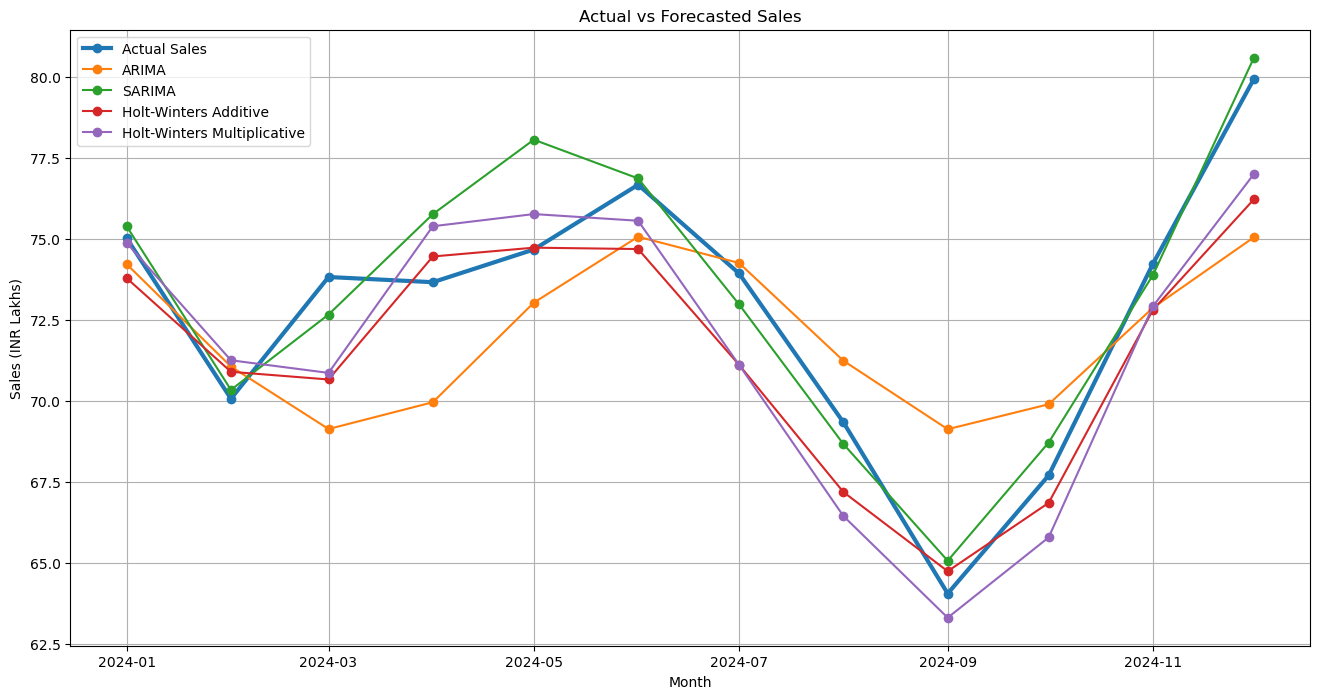

In [42]:
plt.figure(figsize=(16, 8))

plt.plot(
    test.index,
    test,
    marker="o",
    linewidth=3,
    label="Actual Sales"
)

plt.plot(
    test.index,
    arima_forecast,
    marker="o",
    label="ARIMA"
)

plt.plot(
    test.index,
    sarima_forecast,
    marker="o",
    label="SARIMA"
)

plt.plot(
    test.index,
    hw_additive_forecast,
    marker="o",
    label="Holt-Winters Additive"
)

plt.plot(
    test.index,
    hw_multiplicative_forecast,
    marker="o",
    label="Holt-Winters Multiplicative"
)

plt.title("Actual vs Forecasted Sales")
plt.xlabel("Month")
plt.ylabel("Sales (INR Lakhs)")
plt.legend()
plt.grid(True)

plt.show()

In [43]:
# Create next 12 monthly dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

future_dates

DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [44]:
# Fit ARIMA on the complete dataset

final_arima_model = ARIMA(
    df["Sales"],
    order=(best_p, best_d, best_q)
).fit()

final_arima_forecast = final_arima_model.forecast(
    12
)

final_arima_forecast.index = future_dates

In [45]:
# Fit SARIMA on complete dataset

final_sarima_model = SARIMAX(
    df["Sales"],
    order=(
        sarima_p,
        sarima_d,
        sarima_q
    ),
    seasonal_order=(
        sarima_P,
        sarima_D,
        sarima_Q,
        12
    ),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

final_sarima_forecast = final_sarima_model.forecast(
    12
)

final_sarima_forecast.index = future_dates

In [46]:
final_hw_additive_model = ExponentialSmoothing(
    df["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

final_hw_additive_forecast = (
    final_hw_additive_model.forecast(12)
)

final_hw_additive_forecast.index = future_dates

In [47]:
final_hw_multiplicative_model = ExponentialSmoothing(
    df["Sales"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12
).fit()

final_hw_multiplicative_forecast = (
    final_hw_multiplicative_model.forecast(12)
)

final_hw_multiplicative_forecast.index = future_dates

In [48]:
future_forecast_df = pd.DataFrame({
    "Month": future_dates,
    
    "ARIMA Forecast": final_arima_forecast.values,
    
    "SARIMA Forecast": final_sarima_forecast.values,
    
    "Holt-Winters Additive": (
        final_hw_additive_forecast.values
    ),
    
    "Holt-Winters Multiplicative": (
        final_hw_multiplicative_forecast.values
    )
})

future_forecast_df = future_forecast_df.round(2)

display(future_forecast_df)

,Month,ARIMA Forecast,SARIMA Forecast,Holt-Winters Additive,Holt-Winters Multiplicative
0,2025-01-01,79.48,79.79,80.30,81.79
1,2025-02-01,76.21,75.87,77.08,77.48
2,2025-03-01,73.28,78.97,77.72,78.35
3,2025-04-01,73.68,78.78,80.81,82.02
4,2025-05-01,76.93,79.74,81.30,82.69
5,2025-06-01,79.86,81.44,81.74,83.15
6,2025-07-01,79.53,79.05,78.40,78.80
7,2025-08-01,76.31,75.10,74.40,73.71
8,2025-09-01,73.37,70.52,71.45,69.58
9,2025-10-01,73.64,73.67,73.93,72.70


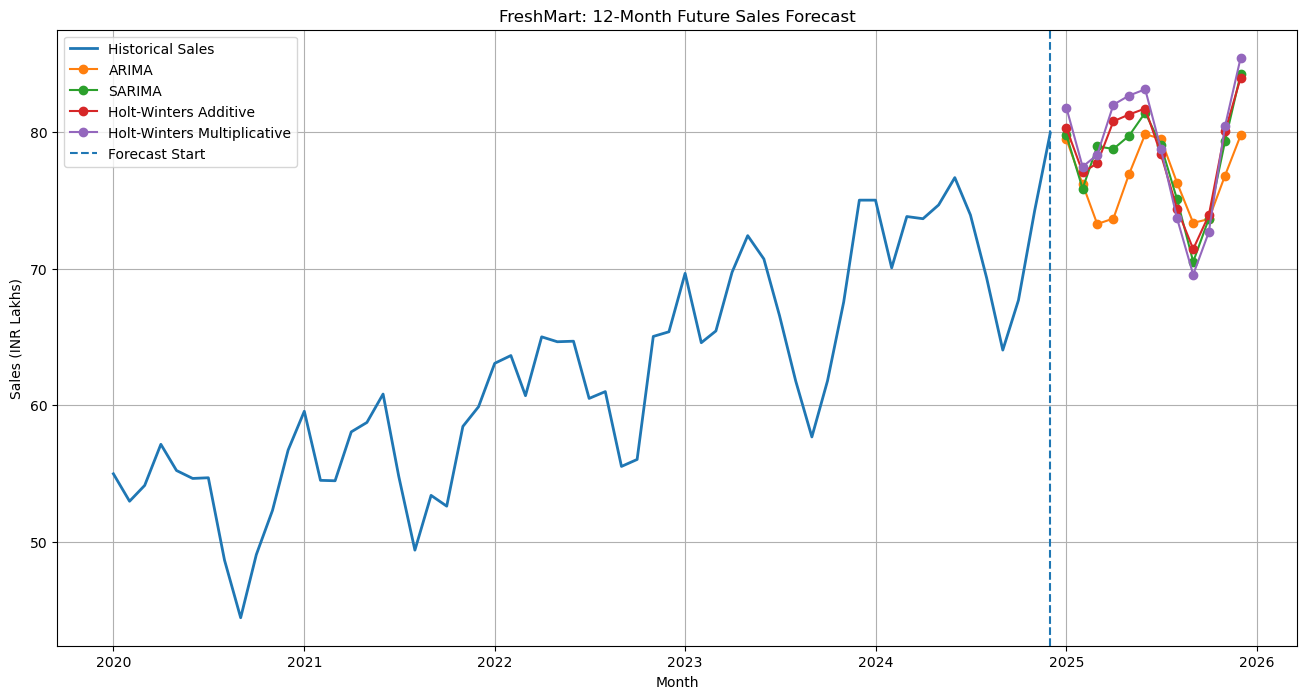

In [49]:
plt.figure(figsize=(16, 8))

# Historical sales
plt.plot(
    df.index,
    df["Sales"],
    linewidth=2,
    label="Historical Sales"
)

# ARIMA
plt.plot(
    future_dates,
    final_arima_forecast,
    marker="o",
    label="ARIMA"
)

# SARIMA
plt.plot(
    future_dates,
    final_sarima_forecast,
    marker="o",
    label="SARIMA"
)

# Holt-Winters Additive
plt.plot(
    future_dates,
    final_hw_additive_forecast,
    marker="o",
    label="Holt-Winters Additive"
)

# Holt-Winters Multiplicative
plt.plot(
    future_dates,
    final_hw_multiplicative_forecast,
    marker="o",
    label="Holt-Winters Multiplicative"
)

plt.axvline(
    df.index[-1],
    linestyle="--",
    label="Forecast Start"
)

plt.title("FreshMart: 12-Month Future Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales (INR Lakhs)")
plt.legend()
plt.grid(True)

plt.show()

In [50]:
future_forecast_df.to_excel(
    "FreshMart_12_Month_Forecast.xlsx",
    index=False
)

print(
    "Excel file created: FreshMart_12_Month_Forecast.xlsx"
)

Excel file created: FreshMart_12_Month_Forecast.xlsx


In [51]:
comparison_df.to_excel(
    "FreshMart_Model_Comparison.xlsx",
    index=False
)

print(
    "Excel file created: FreshMart_Model_Comparison.xlsx"
)

Excel file created: FreshMart_Model_Comparison.xlsx


In [52]:
# Identify the model with the lowest RMSE
best_model_rmse = comparison_df.loc[
    comparison_df["RMSE"].idxmin()
]

# Identify the model with the lowest MAPE
best_model_mape = comparison_df.loc[
    comparison_df["MAPE (%)"].idxmin()
]

print("Model with lowest RMSE:")
print(best_model_rmse["Model"])

print("\nModel with lowest MAPE:")
print(best_model_mape["Model"])

print("\nDetailed results:")
display(comparison_df)

Model with lowest RMSE:
SARIMA(2,1,0)(1,0,0)[12]

Model with lowest MAPE:
SARIMA(2,1,0)(1,0,0)[12]

Detailed results:


,Model,MAE,RMSE,MAPE (%)
0,"SARIMA(2,1,0)(1,0,0)[12]",1.012479,1.338363,1.394398
1,Triple Exponential / Holt-Winters,1.643611,1.967810,2.223610
2,Holt-Winters Additive,1.643611,1.967810,2.223610
3,Holt-Winters Multiplicative,1.738301,1.969726,2.382669
4,"ARIMA(3,1,3)",2.433751,2.927527,3.373783
5,SES,3.317700,4.101398,4.650899
6,Double Exponential,4.010789,4.605123,5.571685
7,AR(1),5.133951,6.417282,6.861511
8,AR(3),7.053241,8.587326,9.453230
9,AR(2),7.257339,8.787243,9.738179
